Logistic regression classifier


In [7]:
import pandas as pd 
disease = pd.read_csv("C:/Machine Learning/Diabetes_dataset/diabetes.csv")
disease.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:

disease.shape

(768, 9)

In [9]:
disease.Outcome.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [10]:
disease[disease.Age>=50].value_counts()

Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI   DiabetesPedigreeFunction  Age  Outcome
0            57       60             0              0        21.7  0.735                     67   0          1
             105      84             0              0        27.9  0.741                     62   1          1
             123      72             0              0        36.3  0.258                     52   1          1
             137      84             27             0        27.3  0.231                     59   0          1
             161      50             0              0        21.9  0.254                     65   0          1
                                                                                                            ..
11           155      76             28             150      33.3  1.353                     51   1          1
12           121      78             17             0        26.5  0.259                     62   0          1
      

In [ ]:
# select the features and target for our model
features_columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
X = disease[features_columns]
y = disease.Outcome

In [12]:
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)

In [13]:
# import the class
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
logreg = LogisticRegression(random_state=16)

# fit the model with data
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

c:\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
# import the metrics class
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[116,   9],
       [ 26,  41]])

Text(0.5, 427.9555555555555, 'Predicted label')

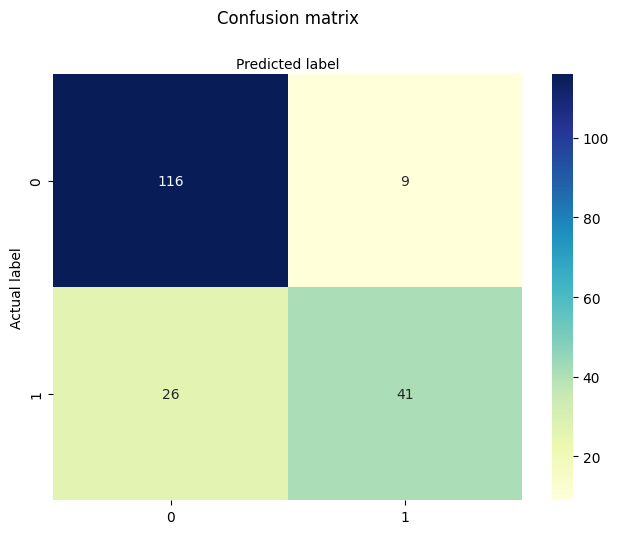

In [15]:
# import required modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

#Text(0.5,257.44,'Predicted label');

In [16]:
from sklearn.metrics import classification_report
target_names = ['without diabetes', 'with diabetes']
print(classification_report(y_test, y_pred, target_names=target_names))

                  precision    recall  f1-score   support

without diabetes       0.82      0.93      0.87       125
   with diabetes       0.82      0.61      0.70        67

        accuracy                           0.82       192
       macro avg       0.82      0.77      0.78       192
    weighted avg       0.82      0.82      0.81       192



In [17]:
disease.head()
disease.info()
disease.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error,root_mean_squared_error


# Load
df = pd.read_csv("C:/Machine Learning/Diabetes_dataset/diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scale (important for stability)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Evaluate
print("R2:", r2_score(y_test, pred) * 100)
print("MSE:", mean_squared_error(y_test, pred))
print("RMSE:", root_mean_squared_error(y_test, pred))
print("predictions:",pred)



R2: 33.30052285551428
MSE: 0.1586207838990131
RMSE: 0.39827224846706694
predictions: [ 0.48011929  0.30724742  0.28366772  0.12027062  0.20029686  0.27266311
  0.26569738  0.2393173   0.09619651  0.70270193  0.16233444 -0.00238667
  0.11706146  0.72873618  0.23075892  0.55696592  0.35787462  0.73705663
 -0.05682485  0.61648153  0.37796036  0.01206136  0.40482294  0.55012081
  0.61604073  0.59302696  0.30880021 -0.05532012 -0.19177068  0.68595717
  0.09174879  0.57880382  0.40774701  0.29539345  0.55905516  0.58550754
 -0.10688741  0.3695253   0.28192839  0.20382071  0.20240009  0.79748544
  0.78439594  0.0946282   0.21462801  0.0439741   0.00438626  0.80186969
  0.53595735  0.04927957  0.33572523  0.35442533  0.46912195  0.24908739
  0.25805793 -0.04924091  0.24008724  0.2836871   0.1099042   0.23626688
  0.52032649  0.19194836  0.48568652  0.61924013  0.51626681 -0.00487992
  0.36685555  0.26247559  1.05653739  0.24647782  0.39604961  0.38362525
  0.27327566  0.06367728  0.48798468  0

In [21]:
disease.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0
